In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_path = "/content/drive/MyDrive/plant_disease_model_9class.pth"
dataset_path = "/content/drive/MyDrive/AgroDetectDataset"  # folder containing class folders


In [ ]:
import os

base_path = "/content/drive/MyDrive/AgroDetectDataset"


print("Folders found:")
print(os.listdir(base_path))


Folders found:
['Tomato_healthy', 'Tomato_Early_blight', 'Potato_Late_blight', 'Pepper_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_Late_blight', 'Potato_healthy', 'Pepper_healthy', 'Potato___Early_blight']


In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = "/content/drive/MyDrive/AgroDetectDataset"

selected_classes = 'Tomato_healthy', 'Tomato_Early_blight', 'Potato_Late_blight', 'Pepper_Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_Late_blight', 'Potato_healthy', 'Pepper_healthy', 'Potato___Early_blight'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Filter dataset
indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in selected_classes
]

from torch.utils.data import Subset
filtered_dataset = Subset(full_dataset, indices)

print("Filtered dataset size:", len(filtered_dataset))


Filtered dataset size: 10079


In [ ]:
train_size = int(0.8 * len(filtered_dataset))
val_size = len(filtered_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    filtered_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 8063
Val size: 2016


In [ ]:
from torchvision import models
import torch.nn as nn

# Load pretrained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Modify final classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 9)  # 9 classes

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {running_loss:.4f}, "
          f"Training Accuracy: {train_accuracy:.2f}%")


Epoch [1/5], Loss: 140.0408, Training Accuracy: 85.18%
Epoch [2/5], Loss: 55.7567, Training Accuracy: 93.79%
Epoch [3/5], Loss: 44.8094, Training Accuracy: 94.56%
Epoch [4/5], Loss: 37.3631, Training Accuracy: 95.32%


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
!rm -rf /content/AgroDetectDataset
!cp -r /content/drive/MyDrive/AgroDetectDataset /content/


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
print(f"Validation Accuracy: {val_accuracy:.2f}%")


Validation Accuracy: 96.68%


In [ ]:
torch.save(model.state_dict(), "plant_disease_model_8class.pth")
print("Model saved successfully.")


Model saved successfully.


In [ ]:
from google.colab import files
files.download("plant_disease_model_8class.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os
!pip install seaborn

In [ ]:
!pip install seaborn

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)
val_loader = DataLoader(dataset, batch_size=32, shuffle=False)

class_names = dataset.classes
print(class_names)


['Pepper_Bacterial_spot', 'Pepper_healthy', 'Potato_Late_blight', 'Potato___Early_blight', 'Potato_healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_healthy']


In [ ]:
device = torch.device("cpu")

model = models.mobilenet_v2(pretrained=False)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 9)

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully.")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully.


100%|██████████| 315/315 [1:05:06<00:00, 12.40s/it]


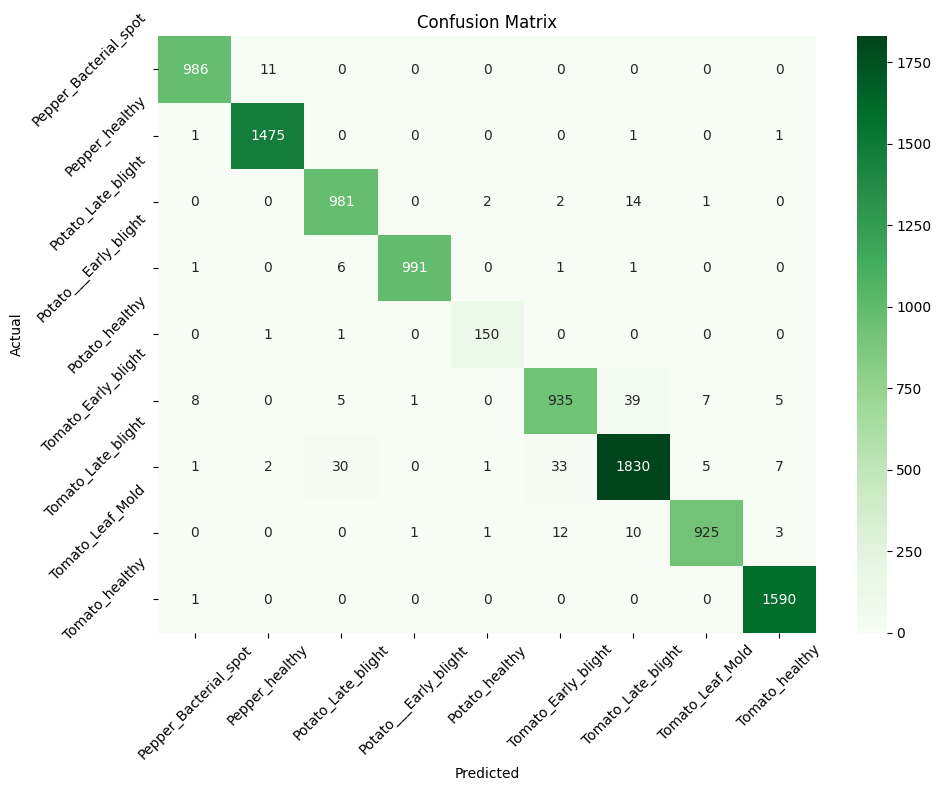

In [ ]:
from tqdm import tqdm

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in tqdm(val_loader):
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
from google.colab import files
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

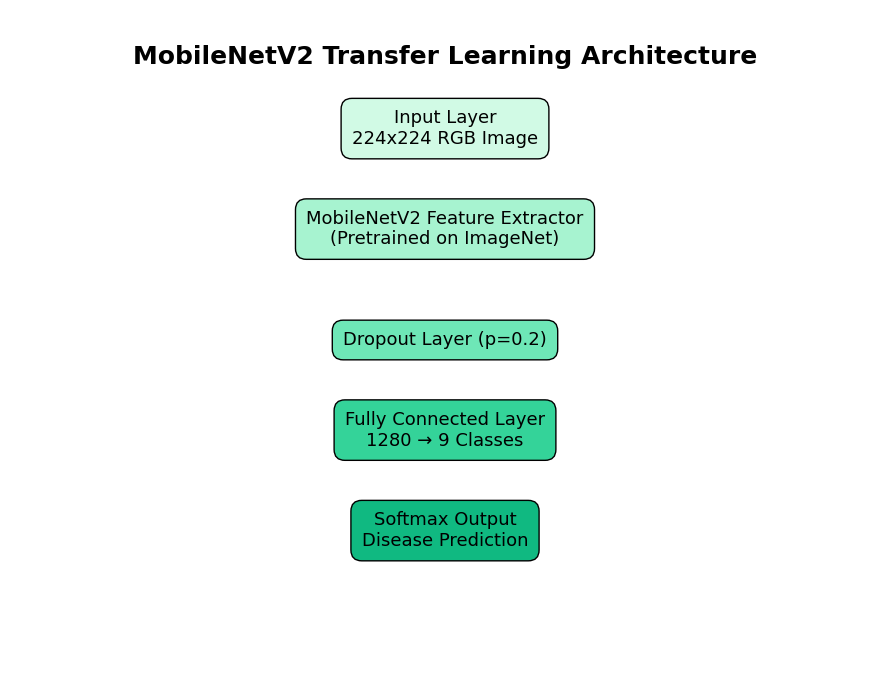

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

# Title
plt.text(0.5, 0.92, "MobileNetV2 Transfer Learning Architecture",
         ha='center', fontsize=18, weight='bold')

# Blocks
blocks = [
    ("Input Layer\n224x224 RGB Image", 0.8),
    ("MobileNetV2 Feature Extractor\n(Pretrained on ImageNet)", 0.65),
    ("Dropout Layer (p=0.2)", 0.5),
    ("Fully Connected Layer\n1280 → 9 Classes", 0.35),
    ("Softmax Output\nDisease Prediction", 0.2)
]

colors = ["#d1fae5", "#a7f3d0", "#6ee7b7", "#34d399", "#10b981"]

for (text, y), color in zip(blocks, colors):
    plt.text(
        0.5, y, text,
        ha='center',
        fontsize=13,
        bbox=dict(facecolor=color, edgecolor="black", boxstyle="round,pad=0.6")
    )

# Remove axes
plt.axis('off')
plt.tight_layout()

plt.savefig("model_architecture.png", dpi=300)
plt.show()


In [ ]:
files.download("model_architecture.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>